In [15]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import prince

In [16]:
data = pd.read_excel('death_2023_c.xlsx')
data

,Cause of Death,Nationwide,Seoul,Busan,Daegu,Incheon,Gwangju,Daejeon,Ulsan,Sejong,Gyeonggi,Gangwon,Chungbuk,Chungnam,Jeonbuk,Jeonnam,Gyeongbuk,Gyeongnam,Jeju
0,Specific Infectious and Parasitic Diseases,37.1,31.1,39.3,37.7,29.2,37.6,36.1,22.6,21.6,26.9,57.6,45.5,47.3,62.1,72,54,41.7,38.3
1,Neoplasms,170.3,149.1,202.2,169.7,162.5,153.8,142.3,145.8,102.5,141.7,209.3,199.7,191.7,218.7,242.6,227.7,202.1,178.4
2,Diseases of the Blood and Blood-Forming Organs...,1.7,1.2,2.5,2.0,1.4,1.5,1,2.1,1.3,1.1,2.4,1.3,2.1,1.8,3.2,2.6,2.5,2.4
3,"Endocrine, Nutritional and Metabolic Diseases",24.8,21.2,34.7,21.1,23.2,15.7,16.4,23.4,9.9,20.1,32.5,27.1,31.5,28.6,33.1,32.6,38.2,20.2
4,Mental and Behavioral Disorders,8.2,5.6,14.9,8.5,10.3,8.9,4.1,11.5,4.4,8.2,5.3,9.1,6.8,6.1,15.8,7.1,6.9,8.9
5,Diseases of the Nervous System,37.1,30.6,44.3,27.7,27,27.9,18,30.3,13.3,27.0,29.3,33.5,41.3,60.4,59.2,58.8,86.9,30.8
6,Diseases of the Ear and Mastoid Process,0.0,-,-,0.1,-,-,-,0.1,-,0.0,-,-,0.0,-,0.1,-,0.0,-
7,Diseases of the Circulatory System,132.1,102.4,177.4,129.2,116,101.5,79.9,119.0,70.8,105.3,174.1,151.2,154.1,203.6,203,203.9,171.6,123.2
8,Diseases of the Respiratory System,89.1,65.9,98.2,103.7,73.3,98.6,85.3,58.7,71,66.3,158.7,121.6,128.2,131.4,155.1,134.7,87.9,76.2
9,Diseases of the Digestive System,27.3,20.3,31.5,26.8,24.8,23.1,21.3,24.9,12.8,22.7,38.7,33.8,32.4,41.3,44.6,37.9,34.1,33


In [17]:
df = data.set_index('Cause of Death')
df.replace('-', 0, inplace=True)
df = df.astype(float)
df

C:\Users\compro\AppData\Local\Temp\ipykernel_2596\1844418025.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace('-', 0, inplace=True)


,Nationwide,Seoul,Busan,Daegu,Incheon,Gwangju,Daejeon,Ulsan,Sejong,Gyeonggi,Gangwon,Chungbuk,Chungnam,Jeonbuk,Jeonnam,Gyeongbuk,Gyeongnam,Jeju
Cause of Death,,,,,,,,,,,,,,,,,,
Specific Infectious and Parasitic Diseases,37.1,31.1,39.3,37.7,29.2,37.6,36.1,22.6,21.6,26.9,57.6,45.5,47.3,62.1,72.0,54.0,41.7,38.3
Neoplasms,170.3,149.1,202.2,169.7,162.5,153.8,142.3,145.8,102.5,141.7,209.3,199.7,191.7,218.7,242.6,227.7,202.1,178.4
Diseases of the Blood and Blood-Forming Organs and Certain Disorders Involving the Immune Mechanism,1.7,1.2,2.5,2.0,1.4,1.5,1.0,2.1,1.3,1.1,2.4,1.3,2.1,1.8,3.2,2.6,2.5,2.4
"Endocrine, Nutritional and Metabolic Diseases",24.8,21.2,34.7,21.1,23.2,15.7,16.4,23.4,9.9,20.1,32.5,27.1,31.5,28.6,33.1,32.6,38.2,20.2
Mental and Behavioral Disorders,8.2,5.6,14.9,8.5,10.3,8.9,4.1,11.5,4.4,8.2,5.3,9.1,6.8,6.1,15.8,7.1,6.9,8.9
Diseases of the Nervous System,37.1,30.6,44.3,27.7,27.0,27.9,18.0,30.3,13.3,27.0,29.3,33.5,41.3,60.4,59.2,58.8,86.9,30.8
Diseases of the Ear and Mastoid Process,0.0,0.0,0.0,0.1,0.0,0.0,0.0,0.1,0.0,0.0,0.0,0.0,0.0,0.0,0.1,0.0,0.0,0.0
Diseases of the Circulatory System,132.1,102.4,177.4,129.2,116.0,101.5,79.9,119.0,70.8,105.3,174.1,151.2,154.1,203.6,203.0,203.9,171.6,123.2
Diseases of the Respiratory System,89.1,65.9,98.2,103.7,73.3,98.6,85.3,58.7,71.0,66.3,158.7,121.6,128.2,131.4,155.1,134.7,87.9,76.2


In [18]:
ca = prince.CA(n_components=2)
ca = ca.fit(df.T)

In [19]:
region_coords = ca.row_coordinates(df.T)
region_coords

,0,1
Nationwide,0.022125,0.013221
Seoul,0.043036,0.024940
Busan,0.075166,0.063927
Daegu,-0.056221,0.011929
Incheon,0.008496,0.095836
Gwangju,-0.091774,0.000711
Daejeon,-0.156508,0.003146
Ulsan,0.091485,0.121981
Sejong,-0.135964,-0.011213
Gyeonggi,0.024594,0.064251


In [20]:
cause_coords = ca.column_coordinates(df.T)
cause_coords

,0,1
Cause of Death,,
Specific Infectious and Parasitic Diseases,-0.063573,-0.072588
Neoplasms,0.002382,0.045459
Diseases of the Blood and Blood-Forming Organs and Certain Disorders Involving the Immune Mechanism,0.061457,0.061736
"Endocrine, Nutritional and Metabolic Diseases",0.112622,0.026645
Mental and Behavioral Disorders,0.052379,0.311076
Diseases of the Nervous System,0.287875,-0.097244
Diseases of the Ear and Mastoid Process,0.055226,0.677247
Diseases of the Circulatory System,0.061151,-0.004739
Diseases of the Respiratory System,-0.123623,-0.068789


In [21]:
from sklearn.cluster import KMeans

In [22]:
kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(region_coords)

c:\Users\compro\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1411: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


C:\Users\compro\AppData\Local\Temp\ipykernel_2596\1921530734.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.scatter(region_coords[0][i], region_coords[1][i], color=color, s=100)
C:\Users\compro\AppData\Local\Temp\ipykernel_2596\1921530734.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.text(region_coords[0][i], region_coords[1][i], df.columns[i], color=color, fontsize=10, ha='center', va='center')


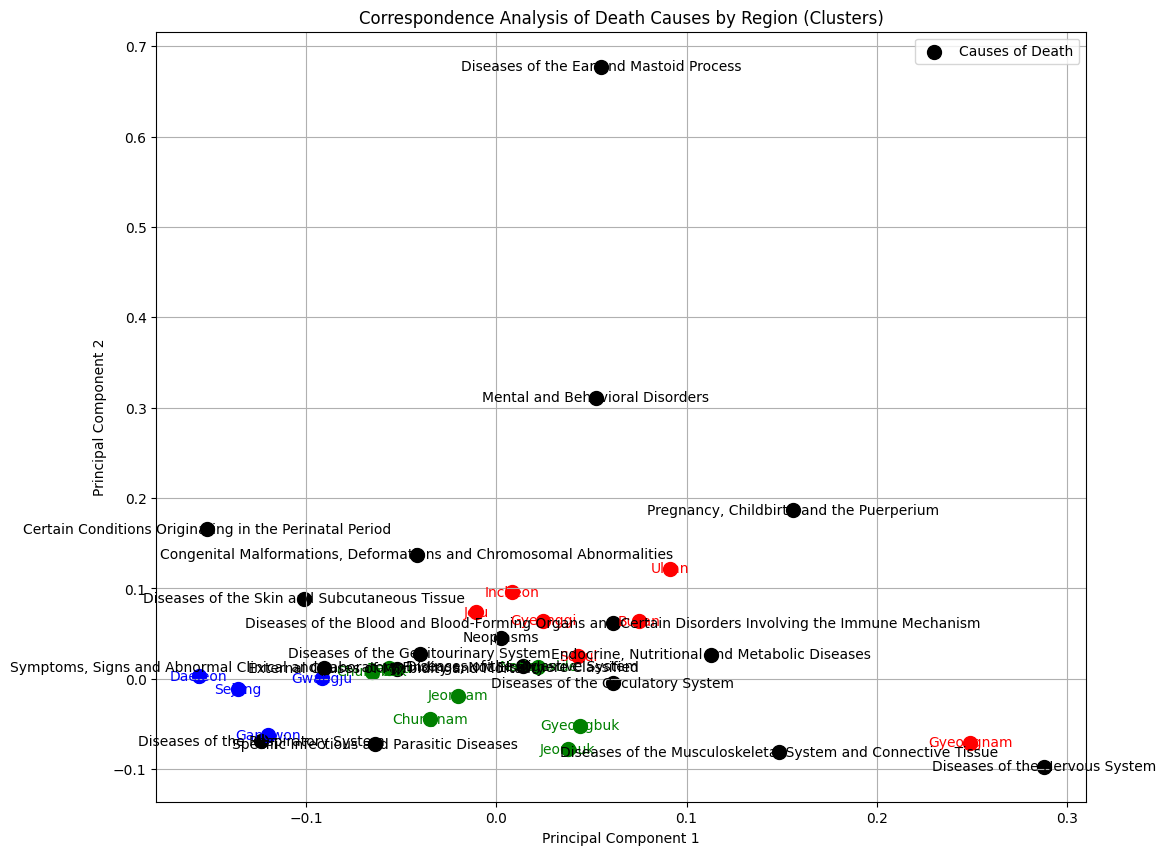

In [23]:
fig, ax = plt.subplots(figsize=(12, 10))
for i, label in enumerate(labels):
    if label == 0:
        color = 'blue'
    elif label == 1:
        color = 'green'
    else:
        color = 'red'
    
    ax.scatter(region_coords[0][i], region_coords[1][i], color=color, s=100)
    ax.text(region_coords[0][i], region_coords[1][i], df.columns[i], color=color, fontsize=10, ha='center', va='center')

cause_coords = ca.column_coordinates(df.T)
ax.scatter(cause_coords[0], cause_coords[1], color='black', label='Causes of Death', s=100)

for i, (x, y) in enumerate(zip(cause_coords[0], cause_coords[1])):
    ax.text(x, y, df.index[i], color='black', fontsize=10, ha='center', va='center')

plt.title('Correspondence Analysis of Death Causes by Region (Clusters)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.legend()
plt.show()

In [24]:
from sklearn.metrics.pairwise import euclidean_distances
import numpy as np

C:\Users\compro\AppData\Local\Temp\ipykernel_2596\4046704562.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = cm.get_cmap('tab20', len(df.index))
C:\Users\compro\AppData\Local\Temp\ipykernel_2596\4046704562.py:23: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  closest_region_x = region_coords[0][closest_region_idx]
C:\Users\compro\AppData\Local\Temp\ipykernel_2596\4046704562.py:24: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  closest_r

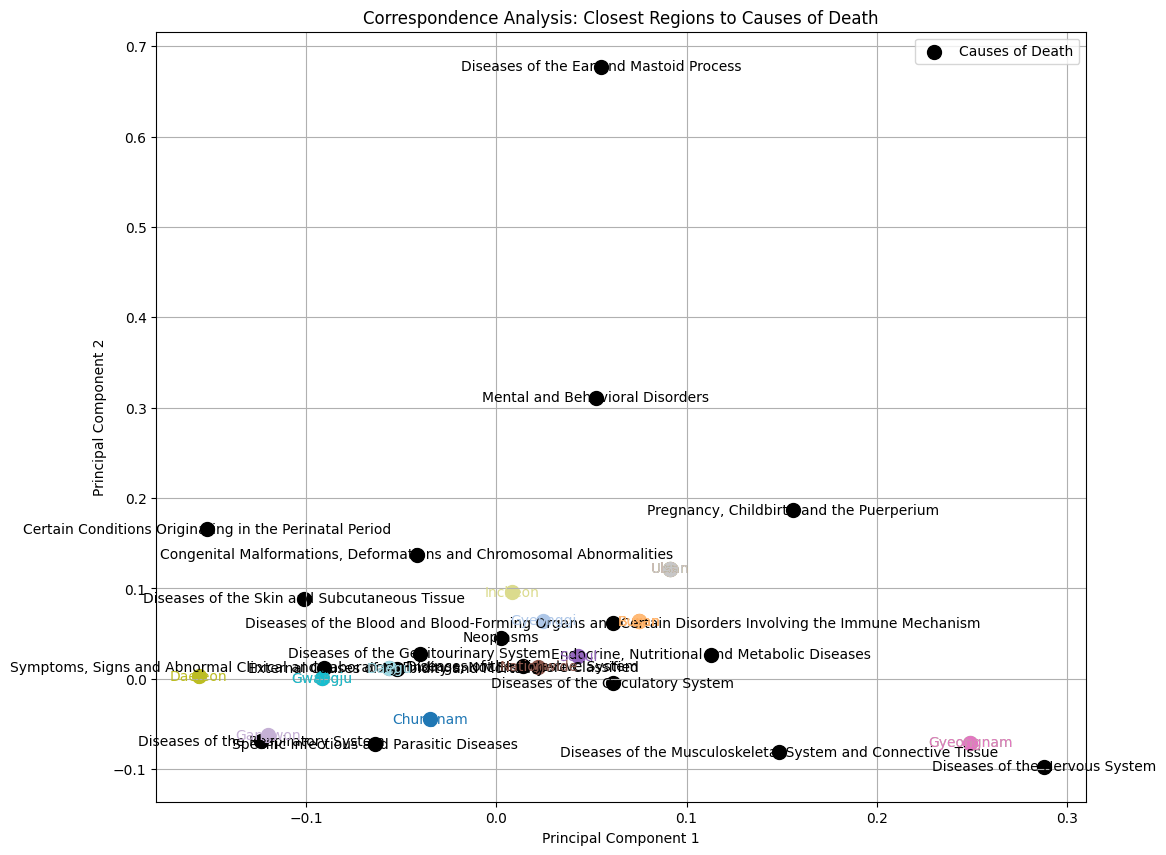

In [25]:
import matplotlib.cm as cm
distances = euclidean_distances(cause_coords, region_coords)  # cause_coords와 region_coords의 크기 맞추기

# 색상 맵 정의 (원인별로 색상 다르게 지정)
colors = cm.get_cmap('tab20', len(df.index))

# 시각화
fig, ax = plt.subplots(figsize=(12, 10))

# 사망 원인에 대해 좌표 플로팅 (검은색 원)
ax.scatter(cause_coords[0], cause_coords[1], color='black', label='Causes of Death', s=100)

# 각 사망 원인에 레이블 추가
for i, (x, y) in enumerate(zip(cause_coords[0], cause_coords[1])):
    ax.text(x, y, df.index[i], color='black', fontsize=10, ha='center', va='center')

# 사망 원인별로 가까운 지역 색상 다르게 묶기
for i, cause in enumerate(cause_coords.T):
    # 사망 원인에 대해 가까운 지역 찾기 (가장 작은 거리)
    closest_region_idx = np.argmin(distances[i])  # 사망 원인에 대해 가장 가까운 지역 인덱스
    
    # 가장 가까운 지역의 좌표
    closest_region_x = region_coords[0][closest_region_idx]
    closest_region_y = region_coords[1][closest_region_idx]
    
    # 각 사망 원인별로 색상 맵을 사용하여 색상을 지정
    color = colors(i)  # i 번째 색상 가져오기

    # 가장 가까운 지역을 해당 사망 원인에 색상을 다르게 지정하여 표시
    ax.scatter(closest_region_x, closest_region_y, color=color, s=100)  # 가장 가까운 지역에 대해 색상 적용
    ax.text(closest_region_x, closest_region_y, df.columns[closest_region_idx], color=color, fontsize=10, ha='center', va='center')

plt.title('Correspondence Analysis: Closest Regions to Causes of Death')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.legend()
plt.show()

C:\Users\compro\AppData\Local\Temp\ipykernel_2596\1520786827.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = cm.get_cmap('tab20', len(df.index))
C:\Users\compro\AppData\Local\Temp\ipykernel_2596\1520786827.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  closest_region_x = region_coords[0][closest_region_idx]
C:\Users\compro\AppData\Local\Temp\ipykernel_2596\1520786827.py:16: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  closest_r

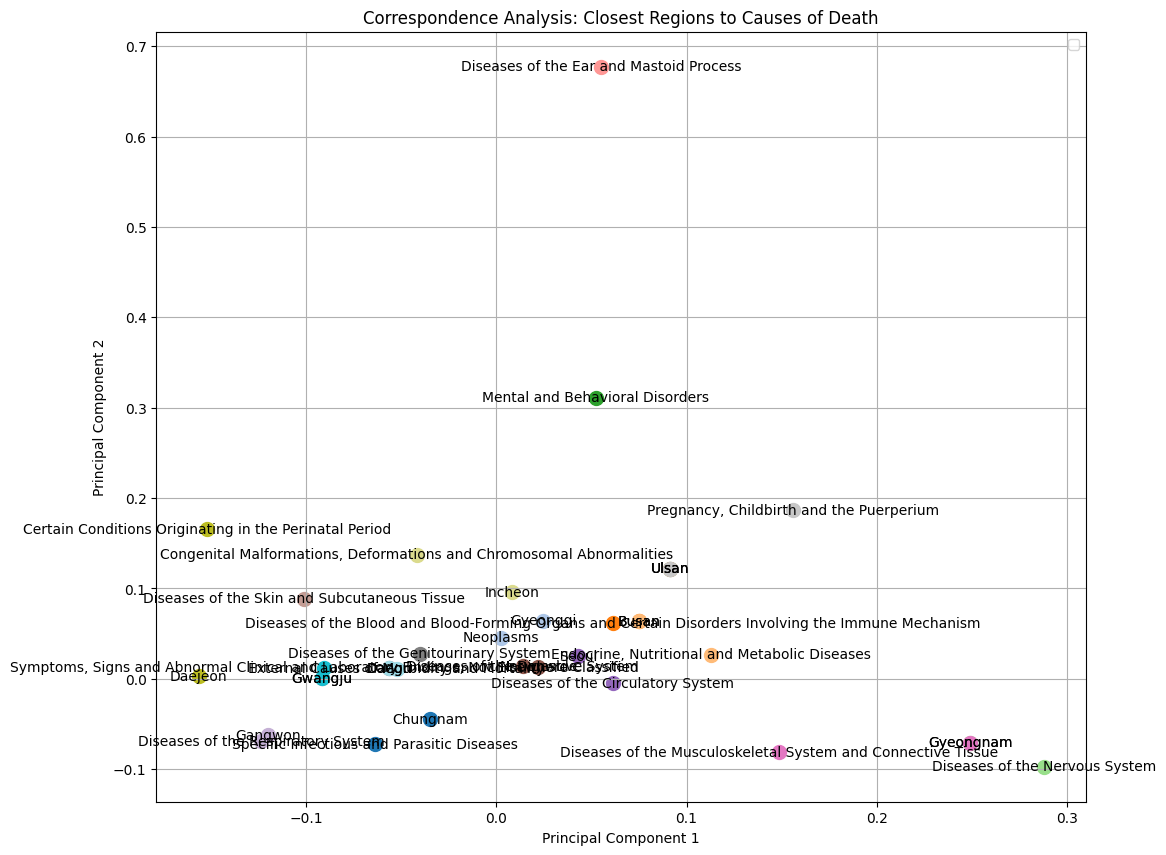

In [26]:
distances = euclidean_distances(cause_coords, region_coords)

# 색상 맵 정의 (원인별로 색상 다르게 지정)
colors = cm.get_cmap('tab20', len(df.index))

# 시각화
fig, ax = plt.subplots(figsize=(12, 10))

# 각 사망 원인에 대해 색상 설정
for i, cause in enumerate(cause_coords.T):
    # 사망 원인에 대해 가장 가까운 지역 찾기 (가장 작은 거리)
    closest_region_idx = np.argmin(distances[i])  # 사망 원인에 대해 가장 가까운 지역 인덱스
    
    # 가장 가까운 지역의 좌표
    closest_region_x = region_coords[0][closest_region_idx]
    closest_region_y = region_coords[1][closest_region_idx]
    
    # 색상 설정: 사망 원인에 대해 색상 맵을 사용하여 색상을 지정
    color = colors(i)  # i 번째 색상 가져오기

    # 사망 원인과 가장 가까운 지역에 동일한 색상 적용
    ax.scatter(cause_coords[0][i], cause_coords[1][i], color=color, s=100)  # 사망 원인에 색상 적용
    ax.text(cause_coords[0][i], cause_coords[1][i], df.index[i], color='black', fontsize=10, ha='center', va='center')

    ax.scatter(closest_region_x, closest_region_y, color=color, s=100)  # 가장 가까운 지역에 색상 적용
    ax.text(closest_region_x, closest_region_y, df.columns[closest_region_idx], color='black', fontsize=10, ha='center', va='center')

plt.title('Correspondence Analysis: Closest Regions to Causes of Death')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.legend()
plt.show()

C:\Users\compro\AppData\Local\Temp\ipykernel_2596\409916998.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = cm.get_cmap('tab20', len(df.index))
C:\Users\compro\AppData\Local\Temp\ipykernel_2596\409916998.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  closest_region_x = region_coords[0][closest_region_idx]
C:\Users\compro\AppData\Local\Temp\ipykernel_2596\409916998.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  closest_regi

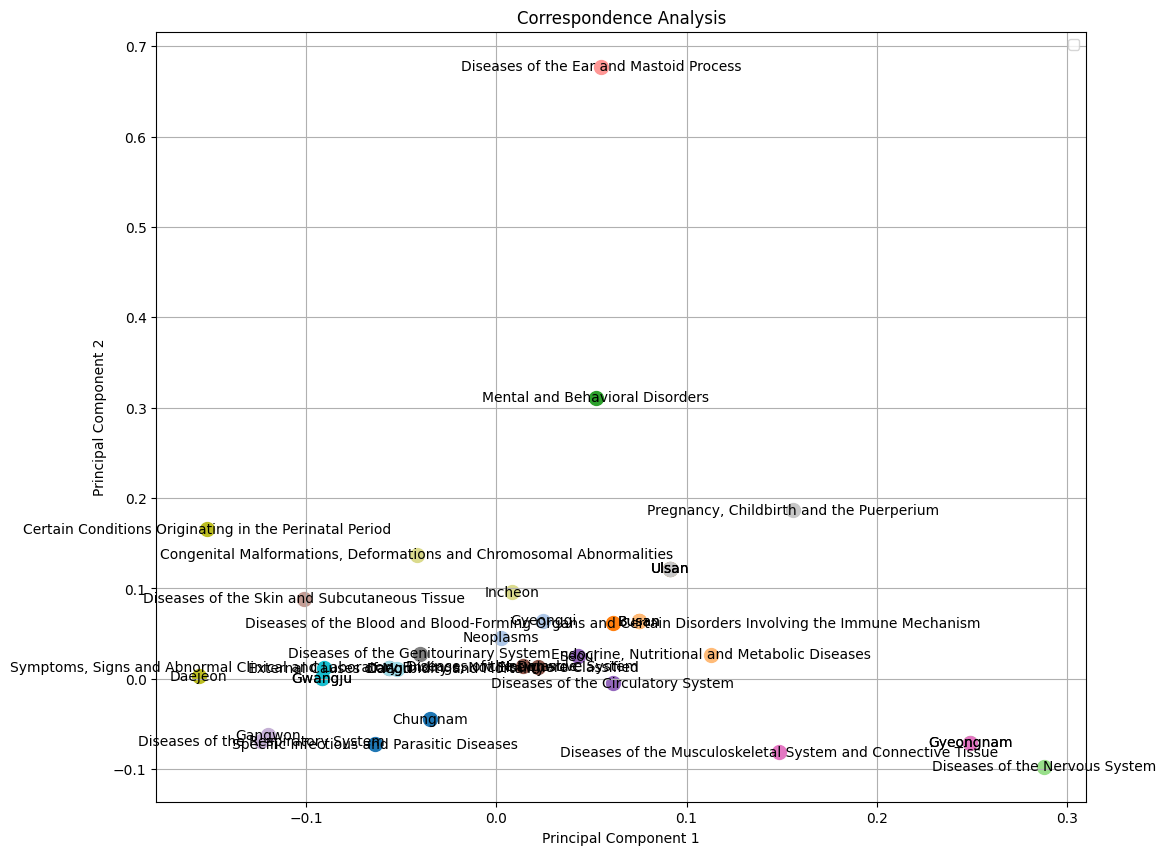

In [27]:
distances = euclidean_distances(cause_coords, region_coords)

colors = cm.get_cmap('tab20', len(df.index))

fig, ax = plt.subplots(figsize=(12, 10))

for i, cause in enumerate(cause_coords.T):
    closest_region_idx = np.argmin(distances[i])  
    
    if not np.isnan(distances[i, closest_region_idx]):  
        closest_region_x = region_coords[0][closest_region_idx]
        closest_region_y = region_coords[1][closest_region_idx]
    
        color = colors(i) 

        ax.scatter(cause_coords[0][i], cause_coords[1][i], color=color, s=100) 
        ax.text(cause_coords[0][i], cause_coords[1][i], df.index[i], color='black', fontsize=10, ha='center', va='center')

        ax.scatter(closest_region_x, closest_region_y, color=color, s=100) 
        ax.text(closest_region_x, closest_region_y, df.columns[closest_region_idx], color='black', fontsize=10, ha='center', va='center')

plt.title('Correspondence Analysis')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.legend()
plt.show()

In [29]:
distances = euclidean_distances(cause_coords, region_coords)

for j, region in enumerate(region_coords.T):
    closest_cause_idx = np.argmin(distances[:, j])  
    if not np.isnan(distances[closest_cause_idx, j]): 
        closest_cause = df.index[closest_cause_idx]  
        print(f"지역: {df.columns[j]} - 가장 가까운 사망 원인: {closest_cause}")

지역: Nationwide - 가장 가까운 사망 원인: Diseases of the Digestive System
지역: Seoul - 가장 가까운 사망 원인: Diseases of the Digestive System
지역: Busan - 가장 가까운 사망 원인: Diseases of the Blood and Blood-Forming Organs and Certain Disorders Involving the Immune Mechanism
지역: Daegu - 가장 가까운 사망 원인: External Causes of Morbidity and Mortality
지역: Incheon - 가장 가까운 사망 원인: Neoplasms
지역: Gwangju - 가장 가까운 사망 원인: Symptoms, Signs and Abnormal Clinical and Laboratory Findings, Not Elsewhere Classified
지역: Daejeon - 가장 가까운 사망 원인: Symptoms, Signs and Abnormal Clinical and Laboratory Findings, Not Elsewhere Classified
지역: Ulsan - 가장 가까운 사망 원인: Diseases of the Blood and Blood-Forming Organs and Certain Disorders Involving the Immune Mechanism
지역: Sejong - 가장 가까운 사망 원인: Symptoms, Signs and Abnormal Clinical and Laboratory Findings, Not Elsewhere Classified
지역: Gyeonggi - 가장 가까운 사망 원인: Neoplasms
지역: Gangwon - 가장 가까운 사망 원인: Diseases of the Respiratory System
지역: Chungbuk - 가장 가까운 사망 원인: External Causes of Morbidity and Mortali